In [1]:
import os
print(os.getcwd())

c:\Users\noelm\OneDrive\Desktop\food-demand-waste-ml\notebooks


In [2]:
import pandas as pd

# df = pd.read_csv ("..\data\raw\retail_sales.csv.csv", parse_dates=["date"])
df = pd.read_csv("../data/raw/retail_sales.csv", parse_dates=['date'])


In [3]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date Range:", df["date"].min(), "to", df["date"].max())
print("Unique Stores:", df["store"].nunique())
print("Unique Items:", df["item"].nunique())
print("Missing Values:\n", df.isnull().sum())

Shape: (913000, 4)
Columns: ['date', 'store', 'item', 'sales']
Date Range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Unique Stores: 10
Unique Items: 50
Missing Values:
 date     0
store    0
item     0
sales    0
dtype: int64


In [5]:
daily_total = df.groupby("date")["sales"].sum()

daily_total.head()

date
2013-01-01    13696
2013-01-02    13678
2013-01-03    14488
2013-01-04    15677
2013-01-05    16237
Name: sales, dtype: int64

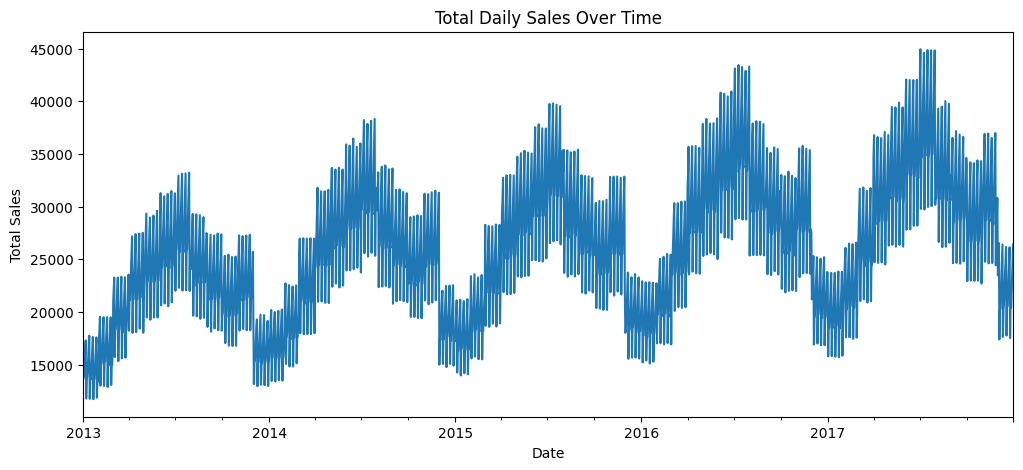

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
daily_total.plot()
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Total Daily Sales Over Time")
plt.axis(True)
plt.show()

In [7]:
daily_total.index = pd.to_datetime(daily_total.index)

weekly_avg = daily_total.groupby(daily_total.index.dayofweek).mean()

weekly_avg

date
0    20714.819231
1    24112.954023
2    24184.252874
3    25861.609195
4    27578.624521
5    29331.348659
6    31071.666667
Name: sales, dtype: float64

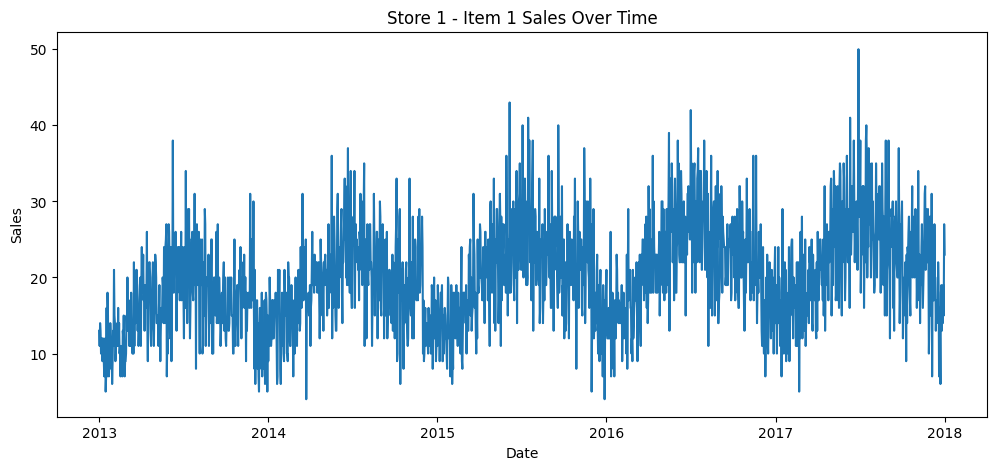

In [8]:
import matplotlib.pyplot as plt

sample = df[(df["store"] == 1) & (df["item"] == 1)].copy()
sample = sample.sort_values("date")
sample = sample.set_index("date")

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["sales"])
plt.title("Store 1 - Item 1 Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Feature Engineering


In [9]:
sample["day_of_week"] = sample.index.dayofweek
sample["month"] = sample.index.month
sample["year"] = sample.index.year

In [10]:
sample['day_of_week']

date
2013-01-01    1
2013-01-02    2
2013-01-03    3
2013-01-04    4
2013-01-05    5
             ..
2017-12-27    2
2017-12-28    3
2017-12-29    4
2017-12-30    5
2017-12-31    6
Name: day_of_week, Length: 1826, dtype: int32

In [11]:
sample["lag_1"] = sample["sales"].shift(1)
sample["lag_7"] = sample["sales"].shift(7)
sample["lag_30"] = sample["sales"].shift(30)

In [12]:
sample.isnull()

,store,item,sales,day_of_week,month,year,lag_1,lag_7,lag_30
date,,,,,,,,,
2013-01-01,False,False,False,False,False,False,True,True,True
2013-01-02,False,False,False,False,False,False,False,True,True
2013-01-03,False,False,False,False,False,False,False,True,True
2013-01-04,False,False,False,False,False,False,False,True,True
2013-01-05,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...
2017-12-27,False,False,False,False,False,False,False,False,False
2017-12-28,False,False,False,False,False,False,False,False,False
2017-12-29,False,False,False,False,False,False,False,False,False


In [13]:
sample = sample.dropna()

In [14]:
sample.isnull()

,store,item,sales,day_of_week,month,year,lag_1,lag_7,lag_30
date,,,,,,,,,
2013-01-31,False,False,False,False,False,False,False,False,False
2013-02-01,False,False,False,False,False,False,False,False,False
2013-02-02,False,False,False,False,False,False,False,False,False
2013-02-03,False,False,False,False,False,False,False,False,False
2013-02-04,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2017-12-27,False,False,False,False,False,False,False,False,False
2017-12-28,False,False,False,False,False,False,False,False,False
2017-12-29,False,False,False,False,False,False,False,False,False


In [15]:
sample.shape

(1796, 9)

In [16]:
#Spliting
train = sample.loc[:'2016-12-31']
test = sample.loc['2017-01-01':]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1431, 9)
Test shape: (365, 9)


In [17]:
sample

,store,item,sales,day_of_week,month,year,lag_1,lag_7,lag_30
date,,,,,,,,,
2013-01-31,1,1,13,3,1,2013,9.0,8.0,13.0
2013-02-01,1,1,11,4,2,2013,13.0,14.0,11.0
2013-02-02,1,1,21,5,2,2013,11.0,12.0,14.0
2013-02-03,1,1,15,6,2,2013,21.0,12.0,13.0
2013-02-04,1,1,14,0,2,2013,15.0,11.0,10.0
...,...,...,...,...,...,...,...,...,...
2017-12-27,1,1,14,2,12,2017,16.0,16.0,10.0
2017-12-28,1,1,19,3,12,2017,14.0,12.0,14.0
2017-12-29,1,1,15,4,12,2017,19.0,6.0,28.0


In [18]:
features = ["day_of_week", "month", "year", "lag_1", "lag_7", "lag_30"]


In [19]:
X_train = train[features]
y_train = train["sales"]

X_test = test[features]
y_test = test["sales"]

In [20]:
y_test

date
2017-01-01    19
2017-01-02    15
2017-01-03    10
2017-01-04    16
2017-01-05    14
              ..
2017-12-27    14
2017-12-28    19
2017-12-29    15
2017-12-30    27
2017-12-31    23
Name: sales, Length: 365, dtype: int64

In [21]:
#Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
print("R²:", round(r2, 4))

R²: 0.39


In [24]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:",round(mae,2))

MAE: 4.38


In [25]:
import numpy as np
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", round(rmse,2))
print("MSE", round(mse,2))

RMSE: 5.42
MSE 29.41


In [26]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", round(mape * 100,2),'%')

MAPE: 23.72 %


In [27]:
print(sample["sales"].mean())

20.129732739420934


In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit



In [29]:
tscv = TimeSeriesSplit(n_splits=5)

In [30]:
param_grid = {
    "max_depth" : [5,7,10,15],
    "min_samples_split" : [2,5,7,10],
    "min_samples_leaf" : [1,2,3,5]
    }

In [31]:
model1 = DecisionTreeRegressor(random_state=42)

grid = GridSearchCV(model1, param_grid = param_grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [32]:
grid.best_params_

{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [33]:
best_model1 = grid.best_estimator_
model1_pred = best_model1.predict(X_test)

In [34]:
mae_d1 = mean_absolute_error(y_test, model1_pred)
rmse_dt = np.sqrt(root_mean_squared_error(y_test, model1_pred))
mape_dt = mean_absolute_percentage_error(y_test, model1_pred)
r2_dt = r2_score(y_test, model1_pred)

print("DT MAE:", round(mae_d1,2))
print("DT RMSE:", round(rmse_dt,2))
print("DT MAPE:", round(mape_dt * 100, 2),"%")
print("R2:",round(r2_dt,2))

DT MAE: 4.53
DT RMSE: 2.38
DT MAPE: 22.49 %
R2: 0.34


In [35]:
modell = DecisionTreeRegressor(max_depth=5)
modell.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [36]:
y = model.predict(X_test)

In [37]:
print("MAE:",mean_absolute_error(y_test, y))
print("RMSE:",np.sqrt(root_mean_squared_error(y_test,y)))
print("R2:",r2_score(y_test, y))

MAE: 4.375175766684768
RMSE: 2.3287414659191676
R2: 0.3900456287591545


In [38]:
#RANDOM FOREST
#Before Tuning
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=300,random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [39]:
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(root_mean_squared_error(y_test, rf_pred))
mape_rf = mean_absolute_percentage_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

print("RF_MAE:", round(mae_rf,2))
print("RF_RMSE:", round(rmse_rf,2))
print("RF_MAPE:", round(mape_rf * 100, 2),"%")
print("RF_R2:",round(r2_rf,2))

RF_MAE: 4.09
RF_RMSE: 2.27
RF_MAPE: 20.87 %
RF_R2: 0.45


In [40]:
param_grid1 = {
    "n_estimators":[200,300,400],
    "max_depth":[6,8,10],
    "min_samples_leaf":[2,5,7,10],
    "max_features":["sqrt",0.8]
}

In [41]:
tscv1 = TimeSeriesSplit(n_splits=5)
rft = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(rft, param_grid=param_grid1,cv=tscv1, scoring="neg_mean_absolute_error" , n_jobs=-1)
grid_rf.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [6, 8, ...], 'max_features': ['sqrt', 0.8], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [42]:
print("BEST RF PARAMS:",grid_rf.best_params_)
print(grid_rf.best_estimator_)
best_rf_t = grid_rf.best_estimator_

BEST RF PARAMS: {'max_depth': 8, 'max_features': 0.8, 'min_samples_leaf': 5, 'n_estimators': 400}
RandomForestRegressor(max_depth=8, max_features=0.8, min_samples_leaf=5,
                      n_estimators=400, random_state=42)


In [43]:
rf_t_pred = best_rf_t.predict(X_test)

In [44]:
mae_rf_tt = mean_absolute_error(y_test, rf_t_pred)
rmse_rf_tt = np.sqrt(root_mean_squared_error(y_test, rf_t_pred))
mape_rf_tt = mean_absolute_percentage_error(y_test, rf_t_pred)
r2_rf_tt = r2_score(y_test, rf_t_pred)

print("RF_MAE_TUNED:", round(mae_rf_tt,2))
print("RF_RMSE_TUNED:", round(rmse_rf_tt,2))
print("RF_MAPE_TUNED:", round(mape_rf_tt * 100, 2),"%")
print("RF_R2_TUNED:",round(r2_rf_tt,2))

RF_MAE_TUNED: 4.09
RF_RMSE_TUNED: 2.27
RF_MAPE_TUNED: 20.76 %
RF_R2_TUNED: 0.45


## FEATURE ENGINEERING

#### Rolling features are:

##### Statistics calculated over a moving window of past values.

They summarize recent history.

Instead of just giving the model:

Yesterday’s sales (lag_1)

Last week’s sales (lag_7)

You give it:

Average of last 7 days

Average of last 30 days

Volatility of last week

That’s much richer information.

##### Why Not Just Use Lag?

#### Lag_7 tells:

What happened exactly 7 days ago.

Rolling mean tells:

What is the general demand trend over the past week.

Rolling mean smooths noise.

#### 🔹 Rolling Std (Volatility)

Rolling standard deviation tells:

How stable or volatile demand has been recently.

High std:

Unstable demand

Harder to predict

Low std:

Stable demand

Easier to predict

That helps tree models split better.

##### Why Rolling Features Are Powerful:

Retail demand often has:

Short-term momentum

Local trend

Weekly cycles

##### Rolling features capture:

Momentum

Smoothing

Level shifts

These are extremely important in time-series forecasting.

In [45]:
sample["rolling_mean_7"] = sample["sales"].shift(1).rolling(7).mean()
sample["rolling_mean_30"] = sample["sales"].shift(1).rolling(30).mean()
sample["rolling_std_7"] = sample["sales"].shift(1).rolling(7).std()



In [46]:
sample = sample.dropna()

In [47]:
print(sample.isnull().sum().sum())

0


In [48]:
#splitting 
train = sample.loc[:'2016-12-31']
test = sample.loc['2017-01-01':]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1401, 12)
Test shape: (365, 12)


In [49]:
features = ['day_of_week', 'month', 'year', 'lag_1', 'lag_7', 'lag_30','rolling_mean_7','rolling_mean_30','rolling_std_7']

In [50]:
X_train = train[features]
y_train = train['sales']

X_test = test[features]
y_test = test['sales']

In [51]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [52]:
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(root_mean_squared_error(y_test, rf_pred))
mape_rf = mean_absolute_percentage_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

print("NEW RF_MAE:", round(mae_rf,2))
print("NEW RF_RMSE:", round(rmse_rf,2))
print("NEW RF_MAPE:", round(mape_rf * 100, 2),"%")
print("NEW RF_R2:",round(r2_rf,2))

NEW RF_MAE: 4.09
NEW RF_RMSE: 2.26
NEW RF_MAPE: 21.29 %
NEW RF_R2: 0.46


In [53]:
param_grid1 = {
    "n_estimators":[200,300,400],
    "max_depth":[6,8,10],
    "min_samples_leaf":[2,5,7,10],
    "max_features":["sqrt",0.8]
}

In [54]:
tscv1 = TimeSeriesSplit(n_splits=5)
rft = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(rft, param_grid=param_grid1,cv=tscv1, scoring="neg_mean_absolute_error" , n_jobs=-1)
grid_rf.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [6, 8, ...], 'max_features': ['sqrt', 0.8], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [55]:
print("BEST RF PARAMS:",grid_rf.best_params_)
print(grid_rf.best_estimator_)
best_rf_t = grid_rf.best_estimator_

BEST RF PARAMS: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'n_estimators': 200}
RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=7,
                      n_estimators=200, random_state=42)


In [56]:
rf_t_pred = best_rf_t.predict(X_test)

In [57]:
mae_rf_tt = mean_absolute_error(y_test, rf_t_pred)
rmse_rf_tt = np.sqrt(root_mean_squared_error(y_test, rf_t_pred))
mape_rf_tt = mean_absolute_percentage_error(y_test, rf_t_pred)
r2_rf_tt = r2_score(y_test, rf_t_pred)

print("RF_MAE_TUNED:", round(mae_rf_tt,2))
print("RF_RMSE_TUNED:", round(rmse_rf_tt,2))
print("RF_MAPE_TUNED:", round(mape_rf_tt * 100, 2),"%")
print("RF_R2_TUNED:",round(r2_rf_tt,2))

RF_MAE_TUNED: 4.03
RF_RMSE_TUNED: 2.24
RF_MAPE_TUNED: 20.83 %
RF_R2_TUNED: 0.47


In [58]:
#XGBoost
from xgboost import XGBRegressor


In [59]:
xgb = XGBRegressor(n_estimators = 300, 
learning_rate = 0.05,
max_depth= 6, 
subsample=0.8,
colsample_bytree=0.8, 
random_state=42)

xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

In [60]:
mae_xgb = mean_absolute_error(y_test, pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred))
mape_xgb = mean_absolute_percentage_error(y_test, pred)
r2_xgb = r2_score(y_test, pred)

print("XGB MAE:", round(mae_xgb, 2))
print("XGB RMSE",round(rmse_xgb,2))
print("XGB MAPE:", round(mape_xgb * 100, 2), "%")
print("XGB R2:", round(r2_xgb, 2))

XGB MAE: 4.08
XGB RMSE 5.19
XGB MAPE: 21.1 %
XGB R2: 0.44


In [61]:
#Tuning XGBoost

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB Params:", grid_xgb.best_params_)

Best XGB Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


In [62]:
best_xgb = grid_xgb.best_estimator_
xgb_pred = best_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_xgb = mean_absolute_percentage_error(y_test, xgb_pred)
r2_xgb = r2_score(y_test, xgb_pred)

print("XGB MAE:", round(mae_xgb, 2))
print("XGB RMSE",round(rmse_xgb,2))
print("XGB MAPE:", round(mape_xgb * 100, 2), "%")
print("XGB R2:", round(r2_xgb, 2))


XGB MAE: 4.05
XGB RMSE 5.05
XGB MAPE: 20.79 %
XGB R2: 0.47


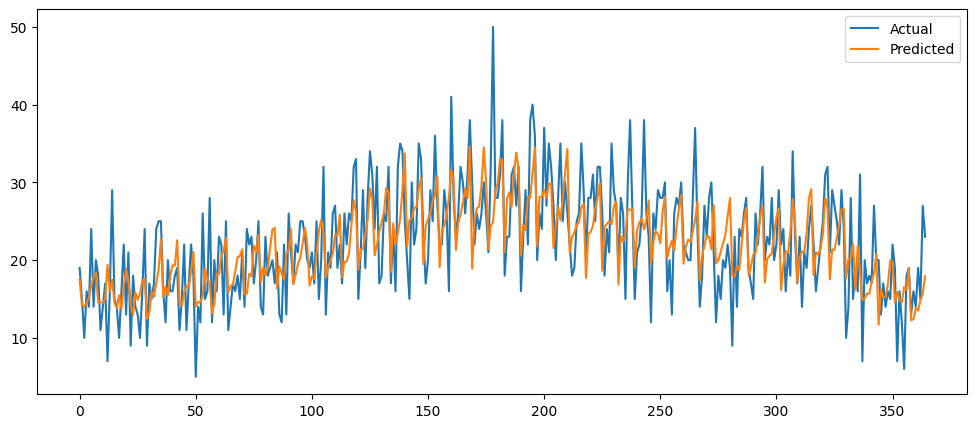

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="Predicted")
plt.legend()
plt.show()

In [64]:
df['date'] = pd.to_datetime(df['date'])

In [65]:
df = df.sort_values(["store", "item", "date"])

In [66]:
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [67]:
df['lag_1'] = df.groupby(['store', 'item'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
df['lag_30'] = df.groupby(['store', 'item'])['sales'].shift(30)

In [68]:
df['rolling_mean_7'] = df.groupby(['store', 'item'])['sales'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df.groupby(['store', 'item'])['sales'].shift(1).rolling(7).std()

In [69]:
df = df.dropna()

In [70]:
train = df[df["date"] <= '2016-12-31']
test = df[df["date"] > '2016-12-31']

In [71]:
features = [
    'store', 'item', 'day_of_week', 'month', 'year', 'lag_1', 'lag_7', 'lag_30','rolling_mean_7','rolling_std_7']
target = "sales"

In [72]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [73]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators = 300, 
learning_rate = 0.05,max_depth= 6, 
subsample=0.8,colsample_bytree=0.8, 
random_state=42)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [74]:
pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred))
mape_xgb = mean_absolute_percentage_error(y_test, pred)
r2_xgb = r2_score(y_test, pred)

print("XGB MAE:", round(mae_xgb, 2))
print("XGB RMSE:", round(rmse_xgb, 2))
print("XGB MAPE:", round(mape_xgb * 100, 2), "%")
print("XGB R2:", round(r2_xgb, 2))

XGB MAE: 6.42
XGB RMSE: 8.35
XGB MAPE: 13.21 %
XGB R2: 0.93


In [ ]:
#Model interpretation

importance = pd.Series(xgb.feature_importances_, index=X_train.columns)

In [77]:
importance

store             0.000858
item              0.000897
day_of_week       0.055967
month             0.005247
year              0.000978
lag_1             0.086384
lag_7             0.171904
lag_30            0.007340
rolling_mean_7    0.668156
rolling_std_7     0.002269
dtype: float32

Text(0.5, 1.0, 'Feature Importance - XGBoost ')

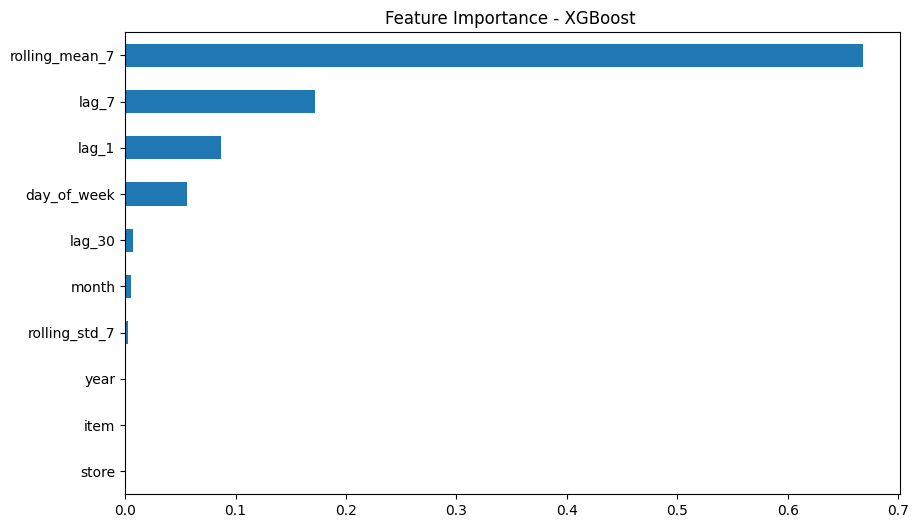

In [81]:
importance.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance - XGBoost ")